In [30]:
import sys
import os
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
sys.path.append('/home/mvargas/code/Huawei/survan')

from lambda_cox import LambdaSA
from utils import get_churn_lastfm_dataset_months, get_churn_kkbox, get_targets_and_masks, train_test_split
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [31]:
from sklearn.preprocessing import StandardScaler

In [34]:
path = '/Users/mariana/Documents/projects/Huawei/SurvanData/lastfm-dataset-1K'
# data_path = '/home/mvargas/code/Huawei/SurvanData/kkbox-churn-prediction-challenge/kkbox'
# data_path = '/Users/mariana/Documents/projects/Huawei/SurvanData/kkbox-churn-prediction-challenge/kkbox/chunk'

In [52]:
df_logs = pd.read_csv(os.path.join(path, 'surv_logs_days.csv'))

In [53]:
df_logs.head()

,Unnamed: 0,userid,day,timestamp,artid_0,artid_1,artid_2,artid_3,artid_4,artid_5,traid_0,traid_1,traid_2,traid_3,traid_4,traid_5,month
0,0,user_000001,2006-08-13,2006-08-13 16:17:43.627451136+00:00,0.039216,0.0,0.274510,0.078431,1.117647,4.039216,1.058824,0.705882,0.0,0.470588,1.529412,4.274510,2006-08
1,1,user_000001,2006-08-15,2006-08-15 14:00:39.249999872+00:00,0.062500,0.0,0.437500,0.125000,2.468750,4.250000,1.406250,0.937500,0.0,0.625000,4.406250,4.500000,2006-08
2,2,user_000001,2006-08-16,2006-08-16 13:01:48.194444288+00:00,0.055556,0.0,0.388889,0.111111,3.194444,5.694444,2.000000,1.333333,0.0,0.888889,5.861111,3.805556,2006-08
3,3,user_000001,2006-08-17,2006-08-17 14:40:57.564102656+00:00,0.000000,0.0,0.000000,0.000000,4.000000,7.000000,9.000000,6.000000,0.0,4.000000,0.000000,3.000000,2006-08
4,4,user_000001,2006-08-18,2006-08-18 19:37:30.727272704+00:00,0.000000,0.0,0.000000,0.000000,4.000000,8.000000,4.090909,2.727273,0.0,1.818182,4.909091,5.181818,2006-08


In [56]:
df_logs.groupby('userid').size().min()

2

In [39]:
len(df_logs.columns)

17

In [4]:
df_logs = pd.read_feather(os.path.join(data_path, 'logs_filtered_preprocessed.feather'))
df_events = pd.read_feather(os.path.join(data_path, 'survival_preprocessed.feather'))
ts = df_events.time
cs = df_events.event
horizon = np.max(ts)

In [27]:
df_logs.head(10)

,num_25,num_50,num_75,num_985,num_100,num_unq,log_minutes,msno
93,2.374906,1.558145e+00,5.596158e-01,6.931472e-01,4.468778,4.241327,5.924668,++4LD1SDe1RuhvmLmnA+Mm1Rx9o1K9xPYA0aNkD9XQg=
111,1.871802,1.098612e+00,1.000000e-07,1.000000e-07,1.386294,2.397895,3.410991,++4yteQFM9k0Gjq5fYL02l14u32iEAgTVHXePKB8zcM=
168,0.559616,-6.453841e-02,-2.876819e-01,7.537718e-01,5.202288,4.881380,6.586592,++7IULiyKbNc8jllqhRuyKZjX1J4mPF4tsudFCJfv4k=
169,0.559616,-6.453841e-02,-2.876819e-01,7.537718e-01,5.202288,4.881380,6.586592,++7IULiyKbNc8jllqhRuyKZjX1J4mPF4tsudFCJfv4k=
170,0.559616,-6.453841e-02,-2.876819e-01,7.537718e-01,5.202288,4.881380,6.586592,++7IULiyKbNc8jllqhRuyKZjX1J4mPF4tsudFCJfv4k=
171,1.791759,1.541508e-01,-4.054650e-01,4.054652e-01,5.089138,4.645992,6.453722,++7IULiyKbNc8jllqhRuyKZjX1J4mPF4tsudFCJfv4k=
172,1.791759,1.541508e-01,-4.054650e-01,4.054652e-01,5.089138,4.645992,6.453722,++7IULiyKbNc8jllqhRuyKZjX1J4mPF4tsudFCJfv4k=
173,1.791759,1.541508e-01,-4.054650e-01,4.054652e-01,5.089138,4.645992,6.453722,++7IULiyKbNc8jllqhRuyKZjX1J4mPF4tsudFCJfv4k=
174,1.517871,1.000000e-07,-2.076392e-01,1.000000e-07,5.138735,4.722398,6.501740,++7IULiyKbNc8jllqhRuyKZjX1J4mPF4tsudFCJfv4k=
175,1.517871,1.000000e-07,-2.076392e-01,1.000000e-07,5.138735,4.722398,6.501740,++7IULiyKbNc8jllqhRuyKZjX1J4mPF4tsudFCJfv4k=


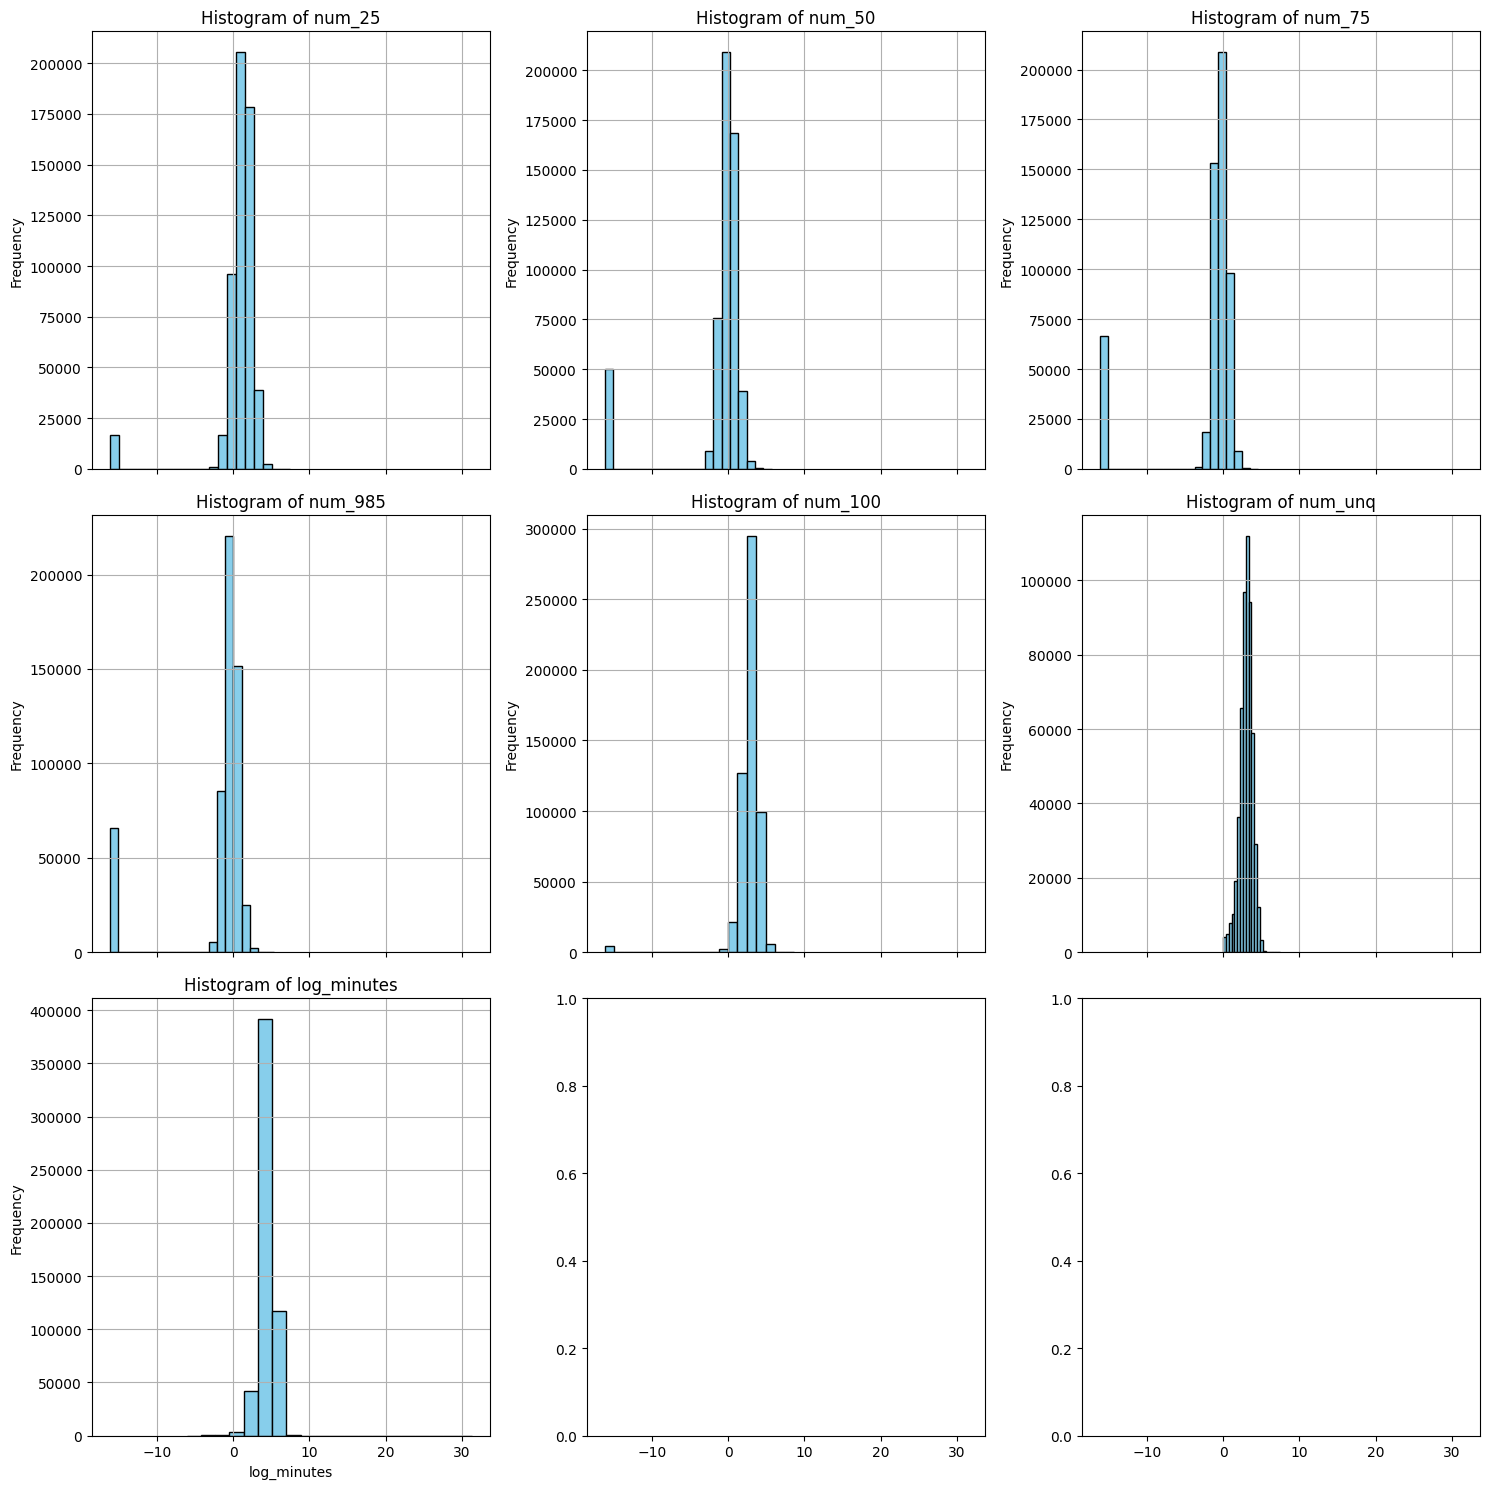

In [11]:
# Create a 2D grid of subplots
num_rows = 3
fig, axs = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows), sharex=True)

# Flatten the axs array to make it easier to iterate
axs = axs.flatten()

cols = ['num_25',	'num_50',	'num_75',	'num_985',	'num_100',	'num_unq',	'log_minutes']

# Loop through the columns and plot histograms
for i, (col, ax) in enumerate(zip(cols, axs)):
    df_logs[col].plot(kind='hist', ax=ax, bins=20, color='skyblue', edgecolor='black')
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

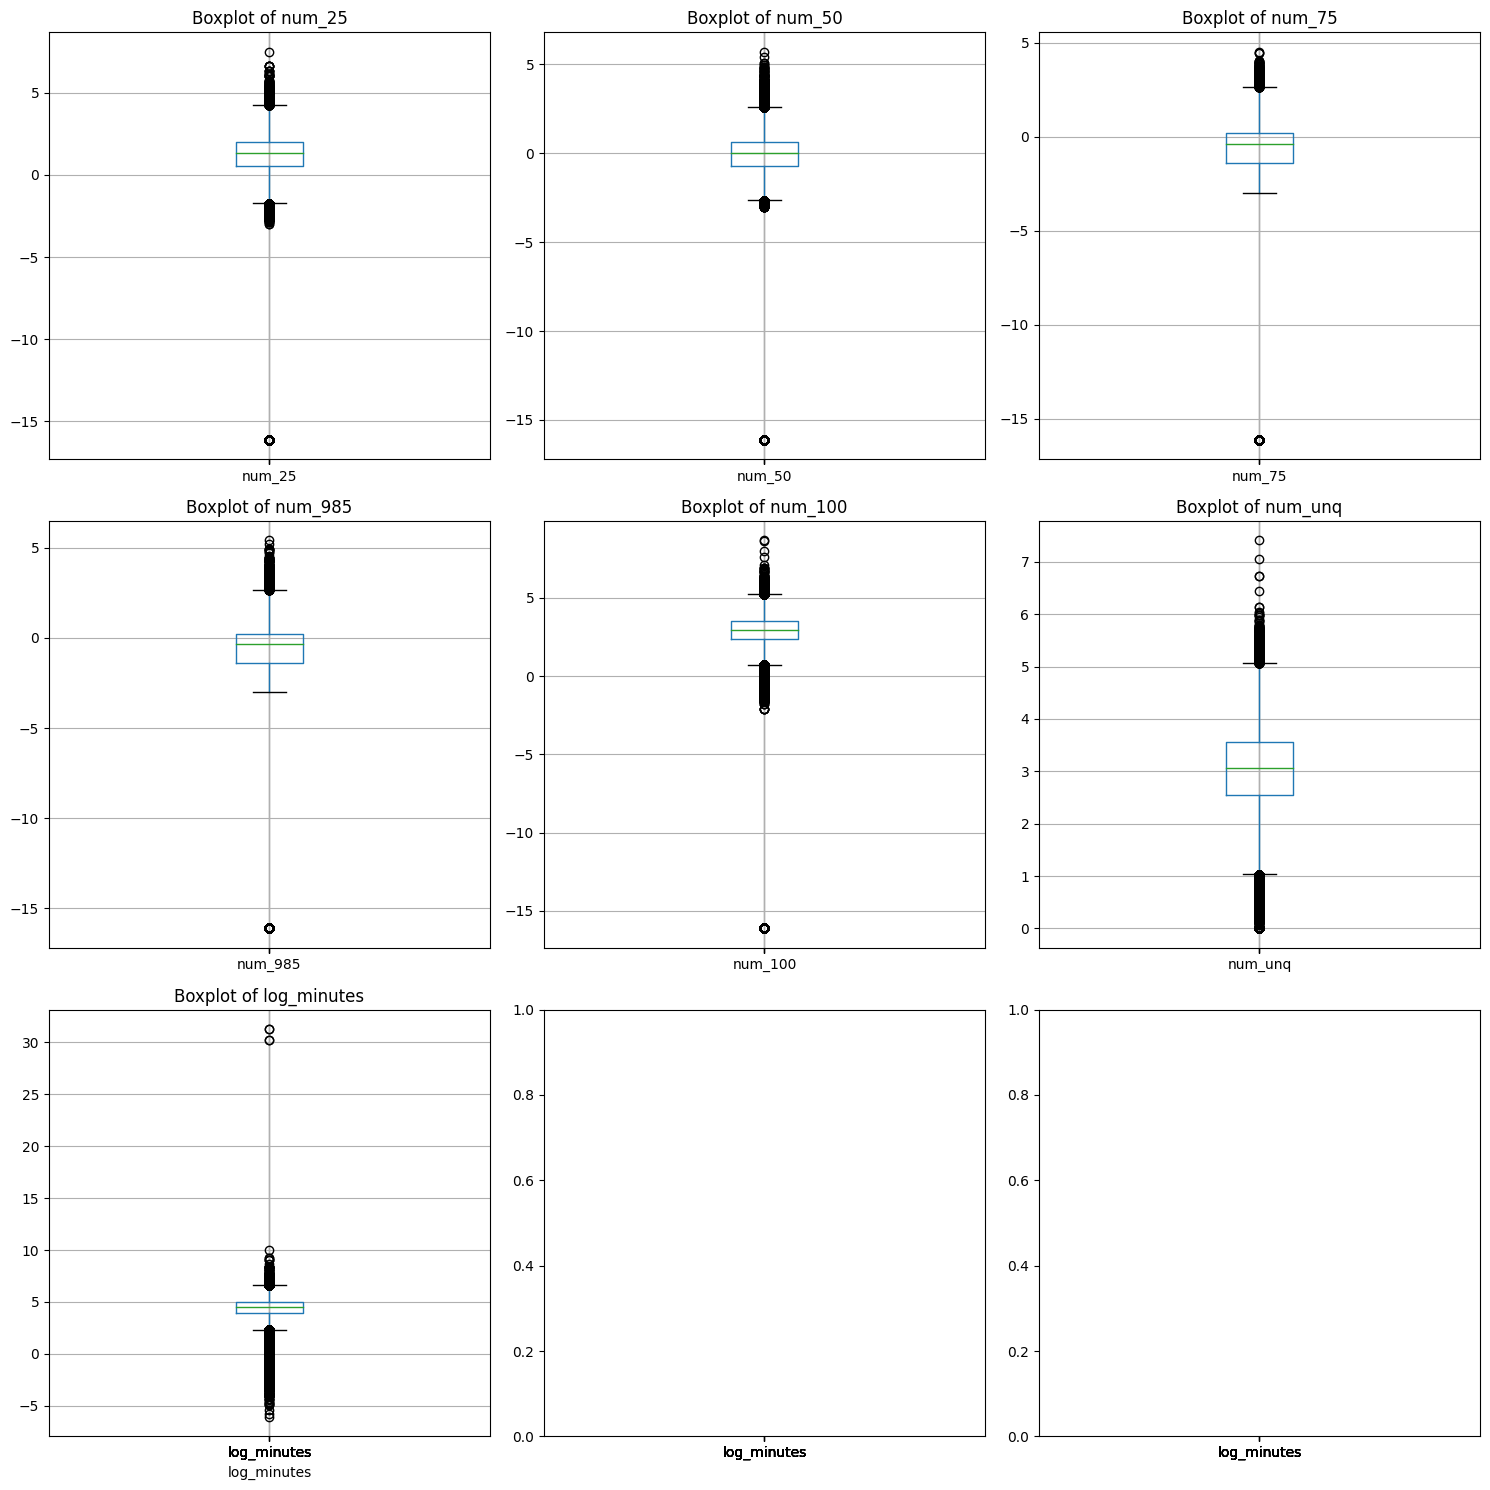

In [13]:
# Create a 2D grid of subplots
num_rows = 3
fig, axs = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows), sharex=True)

# Flatten the axs array to make it easier to iterate
axs = axs.flatten()

cols = ['num_25',	'num_50',	'num_75',	'num_985',	'num_100',	'num_unq',	'log_minutes']

# Loop through the columns and plot histograms
for i, (col, ax) in enumerate(zip(cols, axs)):
    df_logs.boxplot(column=col, ax=ax)
    ax.set_title(f'Boxplot of {col}')
    ax.set_xlabel(col)
    ax.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [18]:
# Standardize the data using StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_logs[cols]), columns=cols)

In [39]:
len(df_scaled)

555433

In [37]:
len(df_logs)

555433

In [47]:
df_scaled['msno'] = df_logs.msno.values

In [48]:
len(df_scaled.groupby('msno'))

136890

In [49]:
len(df_logs.groupby('msno'))

136890

In [50]:
pd.unique(df_logs.msno).shape

(136890,)

In [51]:
pd.unique(df_scaled.msno).shape

(136890,)

In [52]:
len(df_logs)

555433

In [35]:
df_logs.columns

Index(['num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq',
       'log_minutes', 'msno'],
      dtype='object')

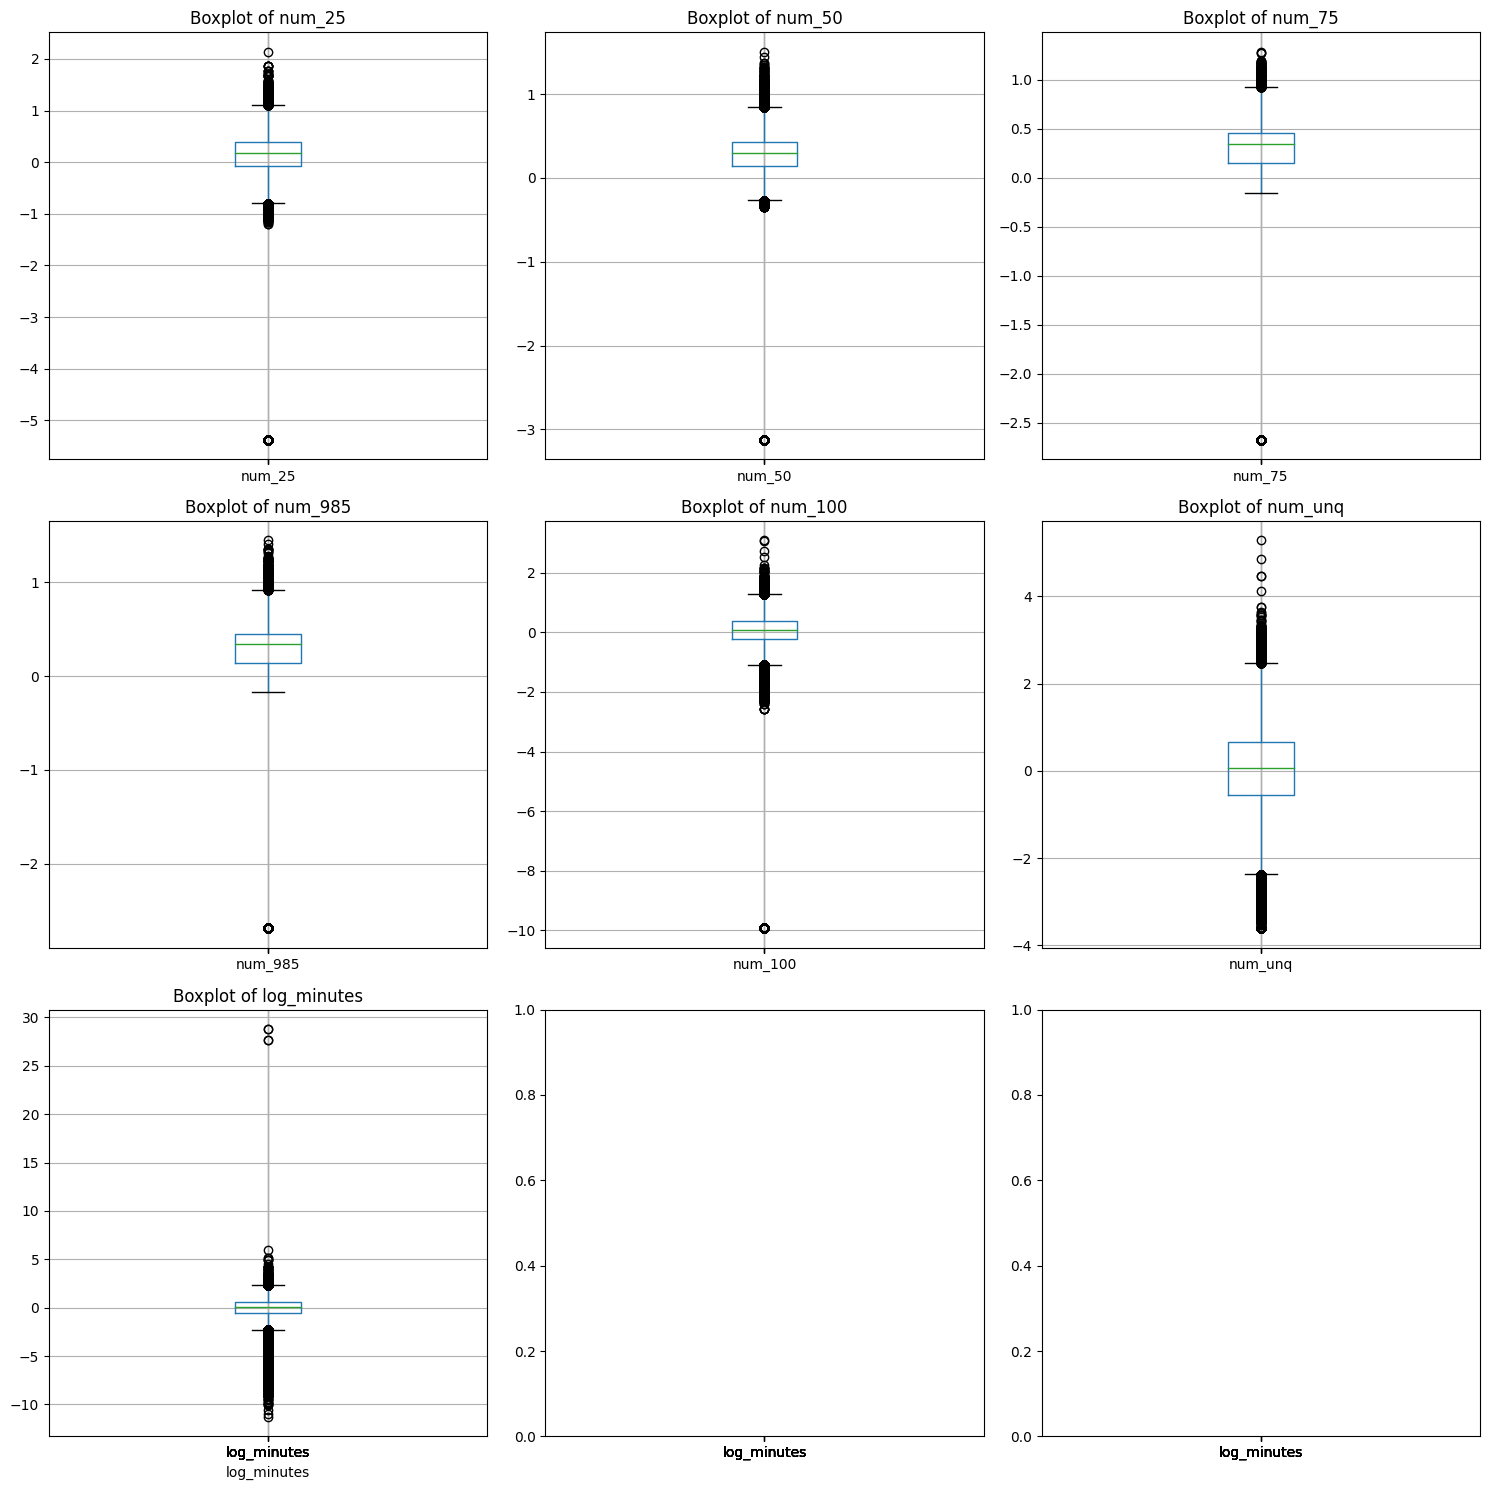

In [19]:
# Create a 2D grid of subplots
num_rows = 3
fig, axs = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows), sharex=True)

# Flatten the axs array to make it easier to iterate
axs = axs.flatten()

cols = ['num_25',	'num_50',	'num_75',	'num_985',	'num_100',	'num_unq',	'log_minutes']

# Loop through the columns and plot histograms
for i, (col, ax) in enumerate(zip(cols, axs)):
    df_scaled.boxplot(column=col, ax=ax)
    ax.set_title(f'Boxplot of {col}')
    ax.set_xlabel(col)
    ax.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [33]:
df_logs[cols] = df_logs[cols].apply(lambda x: np.log1p(x))

/Users/mariana/.Envs/jax310/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [34]:
pd.isna(df_logs).any()

num_25          True
num_50          True
num_75          True
num_985         True
num_100         True
num_unq        False
log_minutes     True
msno           False
dtype: bool

In [7]:
horizon

45

In [5]:
common_index = df_logs.index.intersection(df_events.index)

In [6]:
len(common_index)

1368900

In [7]:
len(df_logs)

5551586

In [8]:
len(df_events)

1368900

In [9]:
df_logs.columns

Index(['num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq',
       'log_minutes', 'msno'],
      dtype='object')

In [10]:
df_events.columns

Index(['msno', 'time', 'event'], dtype='object')

In [12]:
ids = pd.unique(df_events.msno)

In [43]:
chunk = df_events.msno.sample(136890)
max_msno = df_logs.groupby('msno').size().idxmax()
chunk = pd.concat([chunk, pd.Series([max_msno])], ignore_index=True)

In [44]:
chunk.shape

(136891,)

In [45]:
chunk_logs = df_logs[df_logs['msno'].isin(chunk)]
chunk_evnts = df_events[df_events['msno'].isin(chunk)]

In [46]:
print(len(chunk_logs))
print(len(chunk_evnts))

555433
136890


In [47]:
chunk_logs.groupby('msno').size().max()

45

In [50]:
chunk_evnts.event.sum()/len(chunk_evnts)

0.414376506684199

In [51]:
chunk_logs_pth = os.path.join(data_path, 'chunk_logs_filtered_preprocessed.feather')
chunk_evts_pth = os.path.join(data_path, 'chunk_survival_preprocessed.feather')
chunk_logs.to_feather(chunk_logs_pth)
chunk_evnts.to_feather(chunk_evts_pth)

In [52]:
chunk_logs_pth

'/home/mvargas/code/Huawei/SurvanData/kkbox-churn-prediction-challenge/kkbox/chunk_logs_filtered_preprocessed.feather'

In [6]:
data_path = '/Users/mariana/Documents/projects/Huawei/SurvanData/kkbox-churn-prediction-challenge/kkbox/'
df_cov = pd.read_feather(os.path.join(data_path, 'covariates_onehot.feather'))

In [9]:
df_cov.head()

,msno,days_between_subs,days_since_reg_init,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,age_at_start,strange_age,...,payment_method_id_39,payment_method_id_40,payment_method_id_41,registered_via_3,registered_via_4,registered_via_7,registered_via_9,registered_via_10,registered_via_13,registered_via_16
0,+++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=,0,4549,7,0,0,0.0,0.0,28,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,0,1062,410,1788,1788,0.0,0.0,21,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,0,892,30,99,99,1.0,0.0,0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,0,1535,31,149,149,1.0,0.0,24,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,0,2082,30,149,149,1.0,0.0,25,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [10]:
df_cov.days_between_subs.mean()

8.781201772534109

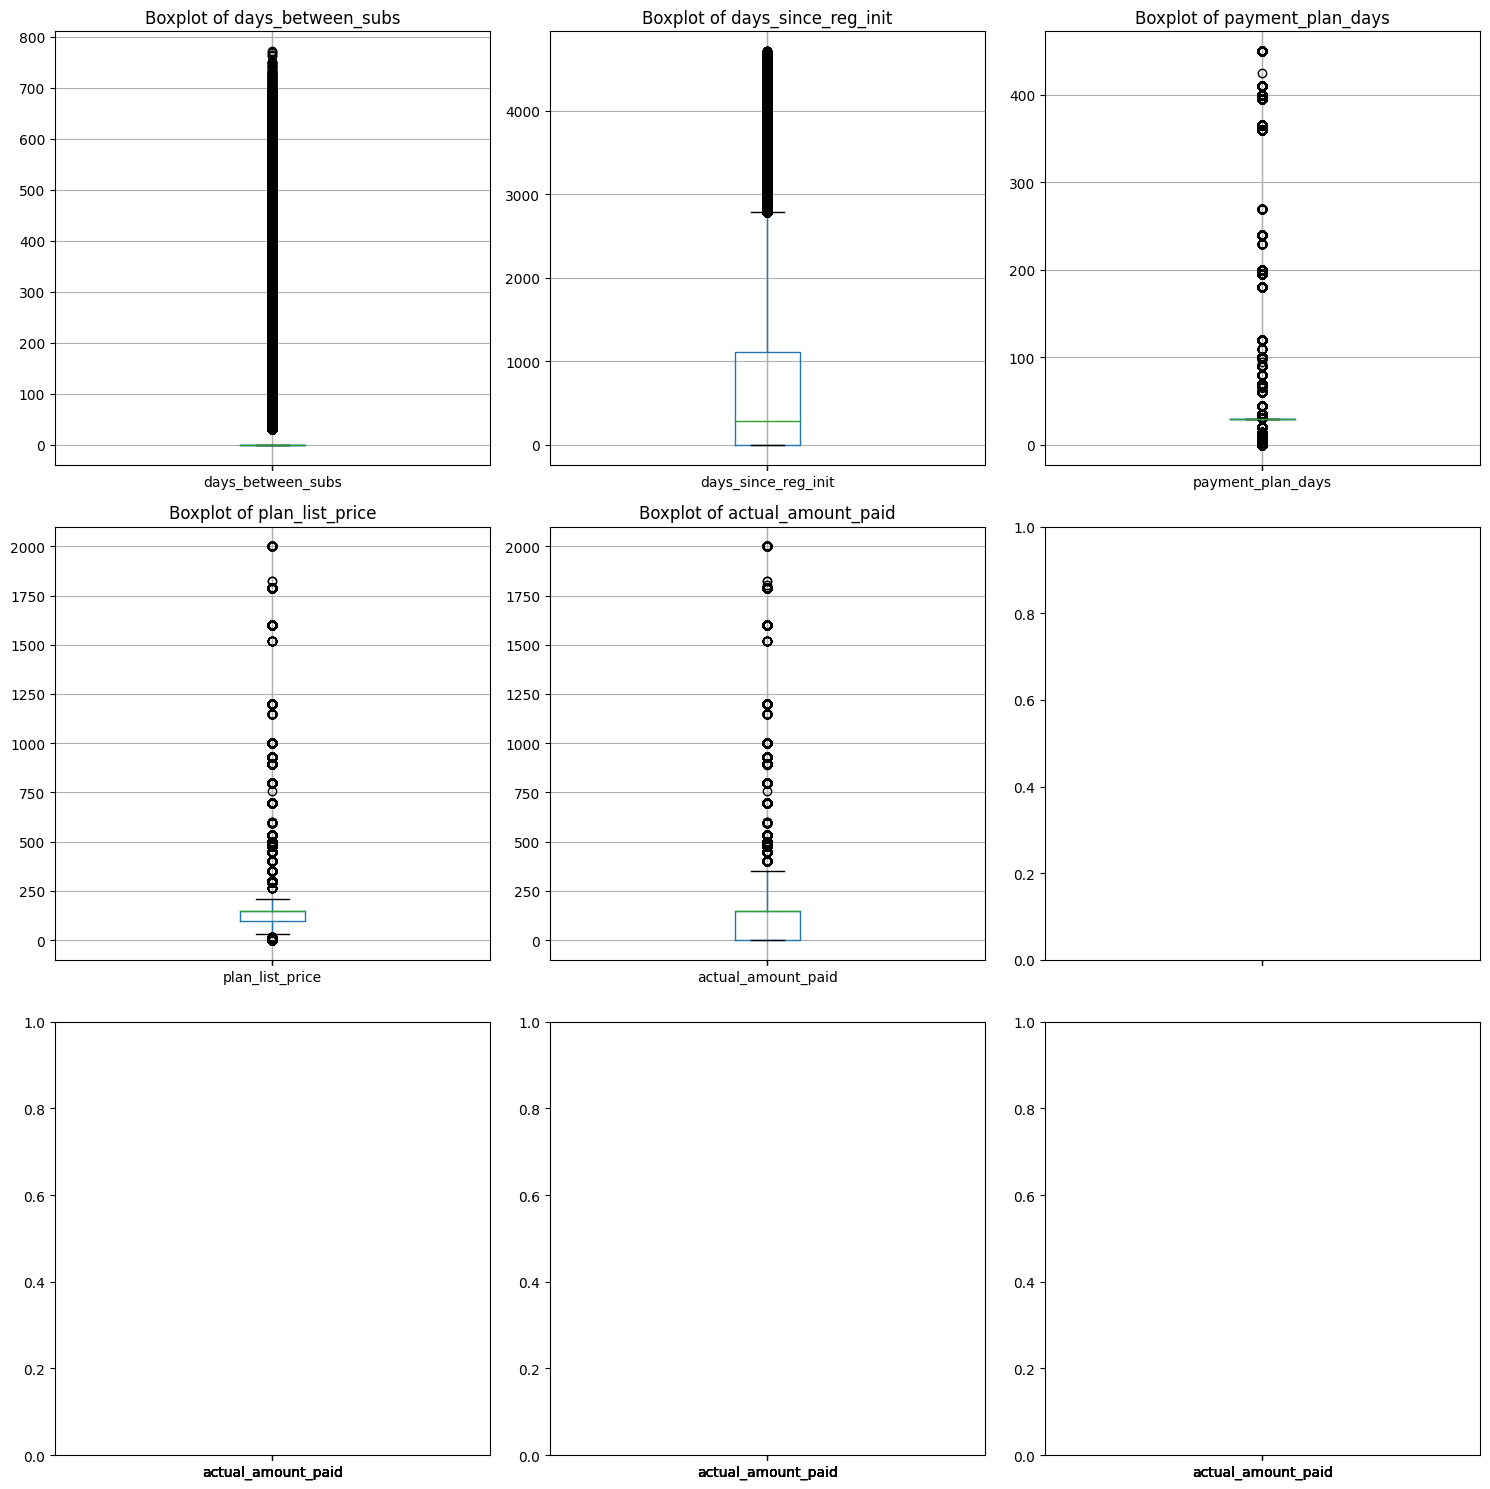

In [11]:
# Create a 2D grid of subplots
num_rows = 2
fig, axs = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows), sharex=True)

# Flatten the axs array to make it easier to iterate
axs = axs.flatten()

cols = ['days_between_subs',
        "days_since_reg_init", 
        "payment_plan_days", 
        "plan_list_price",
        "actual_amount_paid"
        ]

# Loop through the columns and plot histograms
for i, (col, ax) in enumerate(zip(cols, axs)):
    df_cov.boxplot(column=col, ax=ax)
    ax.set_title(f'Boxplot of {col}')
    ax.set_xlabel(col)
    ax.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [15]:
df_logs['msno'].isin(df_cov['msno']).all()

False

In [16]:
not_in_df_cov = df_logs[~df_logs['msno'].isin(df_cov['msno'])]['msno'].tolist()

print("Elements in df_logs.msno not contained in df_cov.msno:", not_in_df_cov)

Elements in df_logs.msno not contained in df_cov.msno: ['mB5zOtUEVpOm/CHw8M176+EiKDY2DCZUkZSZvai1Asg=', 'mB5zOtUEVpOm/CHw8M176+EiKDY2DCZUkZSZvai1Asg=']


In [17]:
len(not_in_df_cov)

2

In [18]:
merged_df = pd.merge(df_cov, df_logs[['msno']], on='msno', how='inner')

In [20]:
len(merged_df)

972555

In [22]:
# List of 'msno' values to drop
keys_to_drop = ['mB5zOtUEVpOm/CHw8M176+EiKDY2DCZUkZSZvai1Asg=', 'another_key']

# Drop rows with 'msno' in the specified list
df_logs = df_logs[~df_logs['msno'].isin(keys_to_drop)]

In [24]:
df_logs[~df_logs['msno'].isin(merged_df['msno'])]['msno'].tolist()

[]

In [26]:
df_logs['msno'].equals(merged_df['msno'])

False

In [27]:
merged_df[~merged_df['msno'].isin(df_logs['msno'])]['msno'].tolist()

[]

In [ ]:
result_df = pd.DataFrame()
grouped_df = df_logs.groupby('msno')
for user_id, group_df in grouped_df:
    prof_row = merged_df[merged_df.msno == user_id]
    repeated_prof = pd.concat(
        [prof_row] * len(group_df), ignore_index=True)
    concatenated_df = pd.concat(
        [group_df.reset_index(drop=True), repeated_prof], axis=1)
    result_df = pd.concat(
        [result_df, concatenated_df], ignore_index=True)

In [ ]:
len(results_df)